E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


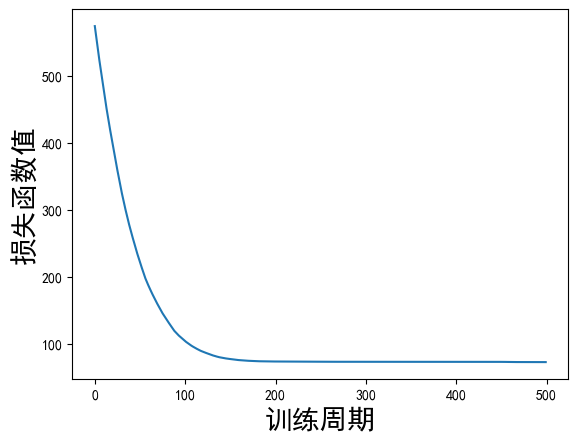

In [10]:
from turtledemo.nim import COLOR

'''
    使用神经网络层实现上面的案例
'''
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#产生随机数
n = 100
x = np.linspace(0,100,n)
y = np.linspace(0,100,n)

#加入噪音
X = x + np.random.uniform(-10,10,n)
Y = y + np.random.uniform(-10,10,n)

#建立模型(仅使用一个神经网络层--->完全连接层)
##定义神经层参数:  input_shape 输入神经元个数 units:输出神经元个数
layer1 = tf.keras.layers.Dense(units=1,input_shape=[1])

##将神经层加入神经网络
model = tf.keras.Sequential([layer1])

#定义模型的损失函数和优化器
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam())

#模型训练
history = model.fit(X,Y,epochs=500,verbose=False)

#可视化结果
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.xlabel('训练周期',fontsize=20)
plt.ylabel('损失函数值',fontsize=20)
plt.plot(history.history['loss'],label='训练损失函数值')

第0轮执行之后的损失值为:   3447.062744140625
第1轮执行之后的损失值为:   440.2947692871094
第2轮执行之后的损失值为:   104.97074890136719
第3轮执行之后的损失值为:   67.57433319091797
第4轮执行之后的损失值为:   63.40361785888672
第5轮执行之后的损失值为:   62.938350677490234
第6轮执行之后的损失值为:   62.886329650878906
第7轮执行之后的损失值为:   62.880393981933594
第8轮执行之后的损失值为:   62.87958908081055
第9轮执行之后的损失值为:   62.87937545776367
第10轮执行之后的损失值为:   62.879215240478516
第11轮执行之后的损失值为:   62.879058837890625
第12轮执行之后的损失值为:   62.878910064697266
第13轮执行之后的损失值为:   62.878761291503906
第14轮执行之后的损失值为:   62.87861251831055
第15轮执行之后的损失值为:   62.878456115722656
第16轮执行之后的损失值为:   62.878299713134766
第17轮执行之后的损失值为:   62.87815475463867
第18轮执行之后的损失值为:   62.87799835205078
第19轮执行之后的损失值为:   62.87785339355469
第20轮执行之后的损失值为:   62.877689361572266
第21轮执行之后的损失值为:   62.877540588378906
第22轮执行之后的损失值为:   62.87739562988281
第23轮执行之后的损失值为:   62.87724304199219
第24轮执行之后的损失值为:   62.87709045410156
第25轮执行之后的损失值为:   62.8769416809082
第26轮执行之后的损失值为:   62.87678527832031
第27轮执行之后的损失值为:   62.87663650512695
第28轮执行之后的损失值为:   62

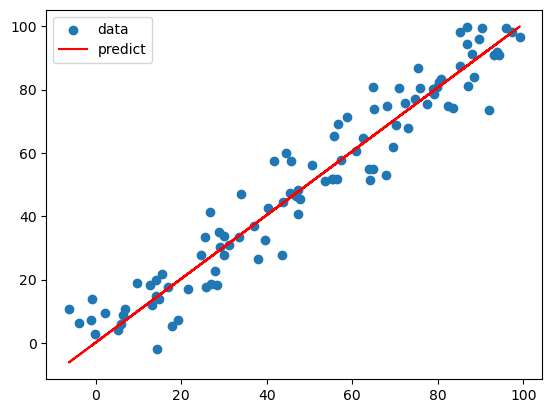

In [12]:
'''
    神经网络求解
'''
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

w = tf.Variable(0.0)
b = tf.Variable(0.0)

#1.定义损失函数MSE
def loss(y,y_pred):
    return tf.reduce_mean(tf.square(y-y_pred))

#定义预测函数
def predict(X):
    return w * X + b

#定义训练函数,传入实际的X与y
def train(X,y,epochs=500,lr = 0.0001):
    for epoch in range(epochs):
        with tf.GradientTape() as t:
            #当前的损失值为预测值与实际值的误差
            current_loss = loss(y,predict(X))
        dw,db = t.gradient(current_loss,[w,b])
        #更新权重  新权重=当前权重-学习率*梯度
        w.assign_sub(lr*dw)
        b.assign_sub(lr*db)
        print(f'第{epoch}轮执行之后的损失值为:   {current_loss}')



#产生样本数据
n = 100
x = np.linspace(0,100,n)
y = np.linspace(0,100,n)

X = x + np.random.uniform(-10,10,n)
y = y + np.random.uniform(-10,10,n)

train(X,y)

print(f'w: {w.numpy()}, b: {b.numpy()}')

#绘制图形
plt.scatter(X,y,label = 'data')
plt.plot(X,predict(X),'r-',label = 'predict')
plt.legend()